<a href="https://colab.research.google.com/github/Western-Windows/SociaLift/blob/engagement/engagement_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Preparing Dependancies**

In [46]:
# 0. Install dependencies (Colab / local with internet)
%pip install -q transformers datasets accelerate sentencepiece scikit-learn torch tqdm emoji

# Imports and configuration and data preparation

In [47]:


import json
import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import emoji
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSeq2SeqLM,
    get_linear_schedule_with_warmup
)

tqdm.pandas()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [48]:
import pandas as pd
import os
import json
from datetime import datetime

class ExperimentTracker:
    def __init__(self, log_path="experiment_history.csv"):
        self.log_path = log_path

    def log_run(self, model_name, accuracy, f1_macro, qwk, experiment_notes="", cm_data=""):
        """Logs the model performance, notes, and the confusion matrix data to a CSV file."""
        new_entry = {
            "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "Model": model_name,
            "Accuracy": round(accuracy, 4),
            "Macro_F1": round(f1_macro, 4),
            "QWK": round(qwk, 4),
            "Notes": experiment_notes,
            "Confusion_Matrix": cm_data  # Now storing the actual numbers
        }

        if os.path.exists(self.log_path):
            df_logs = pd.read_csv(self.log_path)
            df_logs = pd.concat([df_logs, pd.DataFrame([new_entry])], ignore_index=True)
        else:
            df_logs = pd.DataFrame([new_entry])

        df_logs.to_csv(self.log_path, index=False)
        print(f"✅ Logged {model_name} to {self.log_path}")
        return df_logs.tail(5)
from google.colab import drive
drive.mount('/content/drive')

# Update the path to save directly into your Google Drive
tracker = ExperimentTracker(log_path="/content/drive/MyDrive/gp/experiment_history.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Brand Data & Build Follower Map

In [49]:
with open('/content/drive/MyDrive/gp/Facebook_Brand_Data2.json', 'r', encoding='utf-8') as f:
    brand_metadata = json.load(f)

def parse_followers(f_str):
    """Convert '~1.9M', '43K', '450' etc. to an integer."""
    if not isinstance(f_str, str):
        return np.nan
    f_str = f_str.replace('~', '').replace(',', '').strip().upper()
    mult = 1
    if 'K' in f_str:   mult = 1_000;           f_str = f_str.replace('K', '')
    elif 'M' in f_str: mult = 1_000_000;        f_str = f_str.replace('M', '')
    elif 'B' in f_str: mult = 1_000_000_000;    f_str = f_str.replace('B', '')
    try:
        return int(float(f_str) * mult)
    except ValueError:
        return np.nan

# Index both Brand Name and Username (lowercased) for maximum coverage
followers_map = {}
for brand in brand_metadata:
    val = parse_followers(brand.get('Followers', ''))
    for key in [brand.get('Brand Name', ''), brand.get('Username', '')]:
        k = str(key).lower().strip()
        if k:
            followers_map[k] = val

## Alias Map

In [50]:
import json
import re

def generate_aliases():
    # 1. Load data
    with open('/content/drive/MyDrive/gp/Facebook_Brand_Data2.json', 'r', encoding='utf-8') as f:
        brand_data = json.load(f)

    with open('/content/drive/MyDrive/gp/posts_dataset1.json', 'r', encoding='utf-8') as f:
        posts_data = json.load(f)

    # 2. Build the followers_map keys (Lowercased Brand Names)
    # Depending on how your followers_map is built, adjust the key here if it uses Username instead
    followers_map = {item['Brand Name'].lower(): item['Brand Name'] for item in brand_data}

    # 3. Extract unique owing_profile.names from posts
    post_page_names = set()
    for file_entry in posts_data.values(): # Iterate through the file entries (dictionaries)
        if isinstance(file_entry, dict): # Ensure it's a dictionary before trying to get 'data'
            for post in file_entry.get('data', []):
                name = post.get('owing_profile', {}).get('name')
                if name:
                    post_page_names.add(name)

    aliases = {}

    # 4. Process and map the 314 unique names
    for original_name in post_page_names:
        lower_name = original_name.lower()

        # Skip if it already matches a key perfectly
        if lower_name in followers_map:
            continue

        # Clean the name to find the right alias target
        cleaned_name = lower_name

        # Rule A: Remove Arabic subtitles / subtitles after a dash (e.g., "8west - ٨ غرب" -> "8west")
        if ' - ' in cleaned_name:
            cleaned_name = cleaned_name.split(' - ')[0].strip()

        # Rule B: Remove location/branch embeds (e.g., "fox casual (مدينة نصر)")
        cleaned_name = re.sub(r'\s*\(.*\)', '', cleaned_name).strip()

        # Rule C: Strip long store descriptions
        # (e.g., "loly’s brand house - wholesale - retail sale")
        stop_words = [
            'online brands clothes', 'wholesale', 'retail sale',
            'trendy clothing store', 'fashion consulting agency'
        ]
        for word in stop_words:
            if word in cleaned_name:
                cleaned_name = cleaned_name.replace(word, '').strip()

        # Edge cases & Numeric IDs mapping (You can inject specific hardcodes here)
        custom_overrides = {
            '2man jeans wear': '2manjeans2man',
            'the anime house': 'theanimehouse',
            '400 four hundred_egypt': '400.egypt',
            't-shirt company': 'tshirtcompanyy',
            't-shirty': 'tshirtprinteg'
        }

        target = custom_overrides.get(lower_name, cleaned_name)

        # Add to aliases mapping
        aliases[lower_name] = target

    # 5. Output the dictionary in Python format
    print("aliases = {")
    for k, v in sorted(aliases.items()):
        print(f"    {k!r:<50}: {v!r},")
    print("}")

    print(f"\n# Generated exactly {len(aliases)} entries.")
    return aliases

if __name__ == "__main__":
    aliases = generate_aliases()

aliases = {
    '8west - ٨ غرب'                                   : '8west',
    'brands club - online brands clothes store from usa in egypt': 'brands club',
    'brands for men -egypt'                           : 'brands for men -egypt',
    'canvas wear '                                    : 'canvas wear',
    'cizaro - سيزارو'                                 : 'cizaro',
    'comfo wear '                                     : 'comfo wear',
    'creative design - التصميم الإبداعي'              : 'creative design',
    'customize-eg'                                    : 'customize-eg',
    'duocairo'                                        : 'duocairo',
    'ego-your fashion destination'                    : 'ego-your fashion destination',
    'fashion retail group - frg'                      : 'fashion retail group',
    'femi9-egypt'                                     : 'femi9-egypt',
    'genzs '                                          : 'genzs',
    'gounela - جونلة'             

## Load Posts Data & Flatten

In [51]:
with open('/content/drive/MyDrive/gp/posts_dataset1.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

flattened_rows = []
unresolved_pages = set()

for file_key, doc in tqdm(raw_data.items()):
    posts = doc.get('data', [])
    for post in posts:
        row = {}
        owing_profile = post.get('owing_profile', {})

        row['page_name']       = owing_profile.get('name') or owing_profile.get('short_name')
        row['post_text']       = post.get('context')
        row['date_of_publish'] = post.get('published_date')

        # Resolve followers: direct match → alias fallback → NaN
        search_key   = str(row['page_name']).lower().strip()
        resolved_key = aliases.get(search_key, search_key)
        followers_val = followers_map.get(resolved_key, np.nan)
        row['page_followers'] = followers_val

        if pd.isna(followers_val):
            unresolved_pages.add(row['page_name'])

        # Sub-reactions mapped from Arabic labels
        sub_reactions      = post.get('sub_reactions', {}) or {}
        row['like_count']  = sub_reactions.get('أعجبني', 0)
        row['love_count']  = sub_reactions.get('أحببته', 0)
        row['haha_count']  = sub_reactions.get('هاهاها', 0)
        row['wow_count']   = sub_reactions.get('واااو',  0)
        row['sad_count']   = sub_reactions.get('أحزنني', 0)
        row['angry_count'] = sub_reactions.get('أغضبني', 0)
        row['care_count']  = sub_reactions.get('أدعمه',  0)

        row['total_reactions'] = post.get('reaction_count.count', 0)
        row['comments_count']  = post.get('comment_rendering_instance.comments.total_count', 0)
        row['share_count']     = post.get('share_count.count', 0)

        flattened_rows.append(row)

posts_df = pd.DataFrame(flattened_rows)

print(f"\nTotal posts      : {len(posts_df)}")
print(f"Followers matched: {posts_df['page_followers'].notna().sum()}")
print(f"Followers missing: {posts_df['page_followers'].isna().sum()}")
if unresolved_pages:
    print(f"Unresolved pages ({len(unresolved_pages)}) — not present in brand data:")
    for p in sorted(unresolved_pages):
        print(f"  {p!r}")

100%|██████████| 314/314 [00:00<00:00, 626.42it/s]


Total posts      : 12526
Followers matched: 11913
Followers missing: 613
Unresolved pages (16) — not present in brand data:
  'Brands for men -Egypt'
  'Customize-EG'
  'Duocairo'
  'EGO-Your Fashion Destination'
  'Fashion Retail Group - FRG'
  'Femi9-Egypt'
  'Je-x'
  'Motion- موشن'
  'T-shirt Company'
  'T-shirty'
  'Terra-Egypt'
  'The Scoop Politics'
  'VESTITI-EG'
  'ZORIX'
  'تى شيرتك T-shirtk'
  'هُدوم-Hdoum'


## Calculate Weighted Engagement Score

In [52]:
reaction_weights = {
    'like_count' : 1.0,
    'love_count' : 2.0,
    'haha_count' : 1.5,
    'wow_count'  : 1.5,
    'sad_count'  : 0.5,
    'angry_count': 0.5,
    'care_count' : 1.5,
    'share_count': 3.0,
}

# Ensure all numeric columns are properly typed
numeric_cols = list(reaction_weights.keys()) + ['page_followers', 'total_reactions',
                                                  'comments_count', 'share_count']
for col in numeric_cols:
    if col in posts_df.columns:
        posts_df[col] = pd.to_numeric(posts_df[col], errors='coerce')

posts_df['engagement_weighted'] = sum(
    w * posts_df[col].fillna(0) for col, w in reaction_weights.items()
)

# Engagement rate: weighted engagement normalised by follower count
followers_series = posts_df['page_followers'].replace(0, pd.NA)
posts_df['engagement_rate'] = (
    posts_df['engagement_weighted'] / followers_series
).fillna(0)


### Drop rows with no follower data

In [53]:
initial_count = len(posts_df)

# Filter rows with valid followers and text in a cleaner way
posts_df = (posts_df.query("page_followers > 0 and page_followers.notna()")
    .dropna(subset=['post_text']).reset_index(drop=True).copy())

# Log results with specific counts
dropped_total = initial_count - len(posts_df)
print(f"--- Data Cleaning Summary ---")
print(f"Initial rows: {initial_count}")
print(f"Dropped:      {dropped_total}")
print(f"Remaining:    {len(posts_df)}")


--- Data Cleaning Summary ---
Initial rows: 12526
Dropped:      1056
Remaining:    11470


##Label Engagement and saving

In [55]:
from sklearn.preprocessing import RobustScaler
import numpy as np # Importing numpy for the infinite bins later

# 1. Initialize the robust scaler
scaler = RobustScaler()

# 2. Scale the data
posts_df['engagement_rate_scaled'] = scaler.fit_transform(posts_df[['engagement_rate']])

# Define engagement labels
# Using 0.67 split to separate 'high' engagement (top 33%) from 'not_high'
posts_df['engagement_label'] = pd.qcut(
    posts_df['engagement_rate_scaled'],
    q=[0,0.5, 1.0],
    labels=['low','high']
)


# 1. Define the 'normal' range by ignoring the top 5% of outliers
# min_val = posts_df['engagement_rate_scaled'].min()
# realistic_max = posts_df['engagement_rate_scaled'].quantile(0.95) # Caps the math at the 95th percentile

# Calculate the range based ONLY on normal data
# value_range = realistic_max - min_val

# 2. Calculate the exact threshold values for 30% and 60% of the *normal* range
# split_30 = min_val + (value_range * 0.5)
# split_60 = min_val + (value_range * 0.6)

# 3. Define the bin edges
# We use np.inf at the end so that viral outliers are safely swept into the 'high' bin
# bins = [-np.inf, 0.5, np.inf]

# # 4. Use pd.cut to assign labels
# posts_df['engagement_label'] = pd.cut(
#     posts_df['engagement_rate_scaled'],
#     bins=bins,
#     labels=['low','high']
# )

# Print distribution and ranges
print(f"\nEngagement label distribution:")
print(posts_df['engagement_label'].value_counts())

# The observed=False parameter silences a common Pandas warning
print("\nBin ranges:")
print(posts_df.groupby('engagement_label', observed=False)['engagement_rate_scaled'].agg(['min', 'max']))


Engagement label distribution:
engagement_label
low     5735
high    5735
Name: count, dtype: int64

Bin ranges:
                       min           max
engagement_label                        
low              -0.298466     -0.000123
high              0.000123  18449.701534


# EDA Analysis

/tmp/ipykernel_3686/1594018061.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=posts_df, x='engagement_label', order=['low', 'avg', 'high'], palette='viridis')
/tmp/ipykernel_3686/1594018061.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_pages.index, x=top_pages.values, palette='Blues_r')
/tmp/ipykernel_3686/1594018061.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_eng_pages.index, x=top_eng_pages.values, palette='Oranges_r')
/tmp/ipykernel_3686/1594018061.py:58: FutureWarning: 'M' is deprecated and will b

Plots generated successfully.
299 unique pages.
11470 total posts.
         page_name                                          post_text  \
0  2Man Jeans Wear  🔥عرض ال 350 اللي مكسر الدنيا مستمر حتي 23 رمضا...   
1  2Man Jeans Wear  عرض ال 350 مستمر حتي 23 رمضان\n👊🔥اي حاجه 350\n...   
2  2Man Jeans Wear  عرض ال 350 شغال لحد 23 رمضان🔥\nفرع مينيا القمح...   
3  2Man Jeans Wear  من فعاليات اول يوم في العرض 🔥🔥🔥 \nولسا مكملين ...   
4  2Man Jeans Wear  🔥التكرار الاخير لعرض ال 350 اللي مكسر الدنيا \...   

      date_of_publish  page_followers  like_count  love_count  haha_count  \
0 2026-03-07 12:33:15         92000.0          50           0           0   
1 2026-03-07 12:28:10         92000.0          28           1           0   
2 2026-03-07 12:18:31         92000.0          13           1           0   
3 2026-03-05 23:26:41         92000.0          10           1           0   
4 2026-03-02 12:08:04         92000.0        2013          33           1   

   wow_count  sad_count  angry_

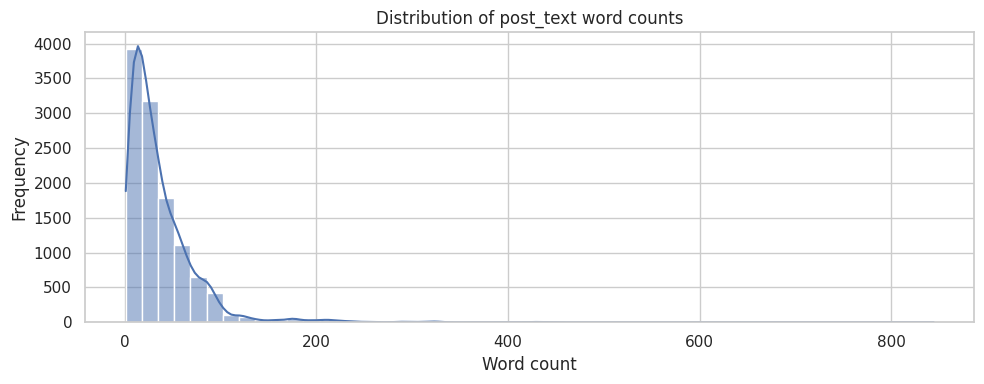

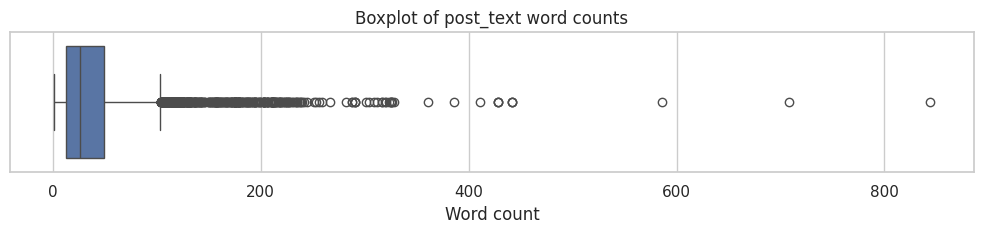

In [56]:
#gemini eda

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nltk
from nltk.corpus import stopwords

# Ensure date is datetime
posts_df['date_of_publish'] = pd.to_datetime(posts_df['date_of_publish'], errors='coerce')

# Set aesthetic style
sns.set_theme(style="whitegrid")

# 1. Distribution of Engagement Label
plt.figure(figsize=(8, 5))
sns.countplot(data=posts_df, x='engagement_label', order=['low', 'avg', 'high'], palette='viridis')
plt.title('Distribution of Engagement Labels')
plt.xlabel('Engagement Label')
plt.ylabel('Count')
plt.savefig('/content/drive/MyDrive/gp/engagement_label_dist.png', bbox_inches='tight')
plt.close()

# 2. Top 10 Pages by Number of Posts
plt.figure(figsize=(10, 6))
top_pages = posts_df['page_name'].value_counts().nlargest(10)
sns.barplot(y=top_pages.index, x=top_pages.values, palette='Blues_r')
plt.title('Top 10 Pages by Number of Posts')
plt.xlabel('Number of Posts')
plt.ylabel('Page Name')
plt.savefig('/content/drive/MyDrive/gp/top_pages_posts.png', bbox_inches='tight')
plt.close()

# 3. Average Engagement Rate by Top 10 Pages
plt.figure(figsize=(10, 6))
top_eng_pages = posts_df.groupby('page_name')['engagement_rate'].mean().nlargest(10)
sns.barplot(y=top_eng_pages.index, x=top_eng_pages.values, palette='Oranges_r')
plt.title('Top 10 Pages by Average Engagement Rate')
plt.xlabel('Average Engagement Rate')
plt.ylabel('Page Name')
plt.savefig('/content/drive/MyDrive/gp/top_eng_pages.png', bbox_inches='tight')
plt.close()

# 4. Correlation Matrix of Metrics
plt.figure(figsize=(10, 8))
corr_cols = ['page_followers', 'like_count', 'love_count', 'haha_count', 'wow_count',
             'sad_count', 'angry_count', 'care_count', 'total_reactions',
             'comments_count', 'share_count', 'engagement_weighted', 'engagement_rate']
corr = posts_df[corr_cols].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Engagement Metrics')
plt.savefig('/content/drive/MyDrive/gp/correlation_heatmap.png', bbox_inches='tight')
plt.close()

# 5. Time Series of Posts over Time
plt.figure(figsize=(12, 5))
posts_df.set_index('date_of_publish').resample('M').size().plot(color='teal', linewidth=2)
plt.title('Number of Posts Over Time (Monthly)')
plt.xlabel('Date of Publish')
plt.ylabel('Post Count')
plt.grid(True)
plt.savefig('/content/drive/MyDrive/gp/posts_over_time.png', bbox_inches='tight')
plt.close()

# Summary statistics for text response
summary_stats = posts_df.describe().to_dict()
missing_values = posts_df.isnull().sum().to_dict()

print("Plots generated successfully.")
print(posts_df['page_name'].nunique(), "unique pages.")
print(posts_df.shape[0], "total posts.")


# Make plots look a bit nicer
sns.set(style="whitegrid")

# 2. Ensure NLTK resources are available
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
    nltk.download('punkt')
    nltk.download('wordnet')

# Quick look at the data
print(posts_df.head())

# 4. Basic text EDA on post_text
posts_df['post_text'] = posts_df['post_text'].astype(str)

# Length features
posts_df['text_length_chars'] = posts_df['post_text'].str.len()
posts_df['text_length_words'] = posts_df['post_text'].str.split().apply(len)

# Summary statistics of lengths
print(posts_df[['text_length_chars', 'text_length_words']].describe())

# Distribution of word counts
plt.figure(figsize=(10, 4))
sns.histplot(posts_df['text_length_words'], bins=50, kde=True)
plt.title('Distribution of post_text word counts')
plt.xlabel('Word count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Boxplot of word counts
plt.figure(figsize=(10, 2.5))
sns.boxplot(x=posts_df['text_length_words'])
plt.title('Boxplot of post_text word counts')
plt.xlabel('Word count')
plt.tight_layout()
plt.show()

# Preprocessing

In [ ]:
translate = True  # Set to True if you want to translate, does it translate correctly?

if translate:
    translation_model_name = "Helsinki-NLP/opus-mt-mul-en"
    trans_tokenizer = AutoTokenizer.from_pretrained(translation_model_name)
    trans_model = AutoModelForSeq2SeqLM.from_pretrained(translation_model_name).to(device)

    def translate_batch(texts, max_length=128, batch_size=16):
        out = []
        for i in tqdm(range(0, len(texts), batch_size), desc="Translating"):
            batch = texts[i:i+batch_size]
            enc = trans_tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_length
            ).to(device)
            with torch.no_grad():
                gen = trans_model.generate(**enc, max_length=max_length)
            decoded = trans_tokenizer.batch_decode(gen, skip_special_tokens=True)
            out.extend(decoded)
        return out

    # Using post_text directly if translation is skipped, or creating the translated column
    posts_df["post_text_en"] = translate_batch(posts_df["post_text"].astype(str).tolist())
else:
    # If no translation, we use the original text for the following steps
    posts_df["post_text_en"] = posts_df["post_text"].astype(str)

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Translating:  40%|███▉      | 285/717 [10:15<15:14,  2.12s/it]

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

#TRIAL 2: EMOJI TRANSLATION
# 1. Translate Emojis to text so the model understands them
def emoji_text(text):
    if not isinstance(text, str):
        return ""
    # Convert emojis to descriptive text (e.g., 🔥 -> :fire:)
    return emoji.demojize(text)

def clean_text(text):
    # Lowercase
    text = text.lower()
    # 2. Clean colons from emojis: :fire: -> fire
    # This helps the tokenizer treat them as words rather than symbols
    text = re.sub(r':(\w+):', r' \1 ', text)

    # Remove URLs (fixed double backslash)
    text = re.sub(r"http\S+", " ", text)

    # Explicitly remove punctuation using string.punctuation (fastest method)
    # This translates all punctuation characters to None (removes them)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove any remaining non-alphanumeric characters (keep spaces)
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Normalize whitespace (fixed double backslash)
    text = re.sub(r"\s+", " ", text).strip()

    return text

def preprocess_text(text):
    emojis = emoji_text(text)
    cleaned = clean_text(emojis)
    tokens = cleaned.split()
    # # Remove stopwords
    # tokens = [t for t in tokens if t not in stop_words]
    # # Lemmatize
    # tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

# 6. Apply preprocessing with progress bar
tqdm.pandas()
posts_df['post_text_clean'] = posts_df['post_text_en'].progress_apply(preprocess_text)

# Inspect original vs cleaned
print(posts_df[['post_text_en', 'post_text_clean']].head())

# 7. Save processed dataset
output_path = '/content/drive/MyDrive/gp/final_dataset_with_followers_processed.csv'
posts_df.to_csv(output_path, index=False)
print(output_path)

# Optional Translation

# Train/validation split and label encoding

In [ ]:

# Make runs reproducible (reduces variance and makes tuning meaningful)
import os
import random
import numpy as np
import torch

seed_val = 42

random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

os.environ["PYTHONHASHSEED"] = str(seed_val)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(seed_val)


label_encoder = LabelEncoder()
posts_df["label_id"] = label_encoder.fit_transform(posts_df["engagement_label"].astype(str))
num_labels = len(label_encoder.classes_)
print("Labels:", list(label_encoder.classes_), "num_labels:", num_labels)

# Stratified split
train_df, val_df = train_test_split(
    posts_df,
    test_size=0.1,
    random_state=seed_val,
    stratify=posts_df["label_id"]
)

print(train_df["label_id"].value_counts(normalize=True).sort_index())
print(val_df["label_id"].value_counts(normalize=True).sort_index())

print("Train size:", len(train_df), "Val size:", len(val_df))

# **Models**

## 1. TF-IDF + Logistic Regression baseline

In [ ]:
from sklearn.metrics import cohen_kappa_score

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3
)

X_train_tfidf = tfidf.fit_transform(train_df["post_text_en"])
X_val_tfidf = tfidf.transform(val_df["post_text_en"])

log_reg = LogisticRegression(
    max_iter=200,
    n_jobs=-1,
    class_weight="balanced"
)
log_reg.fit(X_train_tfidf, train_df["label_id"])

val_pred_lr = log_reg.predict(X_val_tfidf)
val_pred_lr_proba = log_reg.predict_proba(X_val_tfidf)

tfidf_lr_qwk = cohen_kappa_score(val_df["label_id"], val_pred_lr, weights="quadratic")
tfidf_lr_acc = accuracy_score(val_df["label_id"], val_pred_lr)
tfidf_lr_f1 = f1_score(val_df["label_id"], val_pred_lr, average="macro")
print("TF-IDF + LR QWK:", tfidf_lr_qwk)
print("TF-IDF + LR accuracy:",tfidf_lr_acc)
print("TF-IDF + LR macro F1:", tfidf_lr_f1)
print(classification_report(val_df["label_id"], val_pred_lr, target_names=label_encoder.classes_))
# Calculate the confusion matrix
cm = confusion_matrix(val_df["label_id"], val_pred_lr)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title('logistic+tf idf Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# 1. Convert the confusion matrix array to a JSON string
cm_string = json.dumps(cm.tolist())

# 3. Log the baseline WITH the cm_data argument included!
tracker.log_run(
    model_name="TF-IDF + Logistic Regression",
    accuracy=tfidf_lr_acc,
    f1_macro=tfidf_lr_f1,
    qwk=tfidf_lr_qwk,
    experiment_notes="Baseline, with demoji,and log transform, max_features=20k",
    cm_data=cm_string  # <-- This saves the matrix numbers into the CSV
)

In [ ]:
from torch import nn
from transformers import Trainer # Import Trainer class

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        # We store the weights as a tensor to use during training
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Define the custom loss with weights
        # This tells the model how much to 'care' about each class
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

In [ ]:
# import torch.nn.functional as F
# from transformers import Trainer # Added this import

# class FocalLoss(nn.Module):
#     def __init__(self, alpha=1, gamma=2, weight=None):
#         super().__init__()
#         self.alpha = alpha
#         self.gamma = gamma
#         self.weight = weight # Optional class weights

#     def forward(self, logits, labels):
#         # Ensure correct type for mixed precision (FP16)
#         logits = logits.float()
#         ce_loss = F.cross_entropy(logits, labels, weight=self.weight, reduction='none')
#         pt = torch.exp(-ce_loss)
#         focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
#         return focal_loss.mean()

# class FocalTrainer(Trainer):
#     def __init__(self, *args, focal_params=None, **kwargs):
#         super().__init__(*args, **kwargs)
#         self.focal_loss = FocalLoss(**(focal_params or {}))

#     def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
#         labels = inputs.get("labels")
#         outputs = model(**inputs)
#         logits = outputs.get("logits")

#         # Calculate Focal Loss
#         loss = self.focal_loss(logits, labels)

#         return (loss, outputs) if return_outputs else loss

## Transformer models

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback

class TransformerDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts, truncation=True, padding=True, max_length=max_length, return_tensors="pt"
        )
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
        'qwk': cohen_kappa_score(labels, preds, weights='quadratic')
    }

def train_and_evaluate_model(model_name, train_df, val_df, num_labels, target_names, experiment_notes="",
                             learning_rate=2e-5, adam_epsilon=1e-8, warmup_ratio=0.0):
    print(f"\n{'='*50}\nTraining {model_name}\n{'='*50}")

    # 1. Initialize Tokenizer and Model
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        ignore_mismatched_sizes=True # Fixes dimension mismatch on classification heads
    )

    # 2. Create Datasets
    train_dataset = TransformerDataset(train_df["post_text_en"].tolist(), train_df["label_id"].tolist(), tokenizer)
    val_dataset = TransformerDataset(val_df["post_text_en"].tolist(), val_df["label_id"].tolist(), tokenizer)

    # 3. Define Training Arguments
    training_args = TrainingArguments(
        output_dir=f"./results_{model_name.replace('/', '_')}",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        learning_rate=learning_rate,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=50,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        report_to="none", # Disable wandb/wandb logging if not used
        adam_epsilon=adam_epsilon,
        warmup_ratio=warmup_ratio
    )
    # Inside your train_and_evaluate_model function, before Step 4:

    # A. Calculate weights (Example logic: Higher weights for smaller classes)
    # counts: low(1823), high(1820), avg(908)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    weights = torch.tensor([1.0, 2.0, 1.0], dtype=torch.float).to(device)

    # trainer = FocalTrainer(
    # model=model,
    # args=training_args,
    # train_dataset=train_dataset,
    # eval_dataset=val_dataset,
    # compute_metrics=compute_metrics,
    # focal_params={"alpha": 1, "gamma": 2.0}, # You can tune gamma here
    # callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
    # )

    # B. Replace Step 4 (Initialize Trainer) with:
    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
        class_weights=weights # Pass the weights here!
    )
    # # 4. Initialize Trainer
    # trainer = Trainer(
    #     model=model,
    #     args=training_args,
    #     train_dataset=train_dataset,
    #     eval_dataset=val_dataset,
    #     compute_metrics=compute_metrics,
    #     callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
    # )

    # 5. Train and Evaluate
    trainer.train()
    eval_results = trainer.evaluate()

    # 6. Generate Predictions for plots
    predictions = trainer.predict(val_dataset)
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = val_df["label_id"].values

    acc = eval_results['eval_accuracy']
    f1 = eval_results['eval_f1_macro']
    qwk = eval_results['eval_qwk']

    # 7. Print Report & Plot Confusion Matrix
    print(f"\n{model_name} Results:")
    print(f"Accuracy: {acc:.4f} | Macro F1: {f1:.4f} | QWK: {qwk:.4f}") # Added QWK to print
    print(classification_report(labels, preds, target_names=target_names))

    # Calculate the confusion matrix
    cm = confusion_matrix(labels, preds)

    # Plot it for you to see right now in the notebook
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    # NEW: Convert the numpy array into a string representation to save in the CSV
    cm_string = json.dumps(cm.tolist())

    # 8. Log the results to our tracker
    tracker.log_run(
        model_name=model_name,
        accuracy=acc,
        f1_macro=f1,
        qwk=qwk,
        experiment_notes=experiment_notes,
        cm_data=cm_string # Pass the string of numbers here!
    )

    return trainer, predictions.predictions

In [ ]:
# Make sure you run %pip install sentencepiece before using DeBERTa/XLM
import gc
target_names = list(label_encoder.classes_)
experiment_notes = "with demoji,and log transform, 50 epochs,weighted class, lr=2e-5"

# # 1. BERT
bert_trainer, bert_probs = train_and_evaluate_model(
    "bert-base-uncased", train_df, val_df, num_labels, target_names, experiment_notes
)

# FREE GPU MEMORY
del bert_trainer
gc.collect()
torch.cuda.empty_cache()

# # 2. RoBERTa
roberta_trainer, roberta_probs = train_and_evaluate_model(
    "roberta-base", train_df, val_df, num_labels, target_names, experiment_notes
)

# FREE GPU MEMORY
del roberta_trainer
gc.collect()
torch.cuda.empty_cache()


# # 3. XLM-RoBERTa
xlm_trainer, xlm_probs = train_and_evaluate_model(
    "xlm-roberta-base", train_df, val_df, num_labels, target_names, experiment_notes
)

# FREE GPU MEMORY
del xlm_trainer
gc.collect()
torch.cuda.empty_cache()

# 4. DeBERTa-v3 (Isolated Cell)

deberta_trainer, deberta_probs = train_and_evaluate_model(
    "microsoft/deberta-v3-base",
    train_df,
    val_df,
    num_labels,
    target_names,
    experiment_notes=experiment_notes,
    # OVERRIDING THE DEFAULTS:
    learning_rate=1e-5,
    adam_epsilon=1e-6,
    warmup_ratio=0.1
)

# 5. ModernBERT
modern_trainer, modern_probs = train_and_evaluate_model(
    "answerdotai/ModernBERT-base", train_df, val_df, num_labels, target_names, experiment_notes
)

del modern_trainer
gc.collect()
torch.cuda.empty_cache()

# 6. DistilBERT (ADDED)
distilbert_trainer, distilbert_probs = train_and_evaluate_model(
    "distilbert/distilbert-base-uncased", train_df, val_df, num_labels, target_names, experiment_notes
)
del distilbert_trainer
gc.collect()
torch.cuda.empty_cache()